Dataset Shape
(569, 32)


First Five Rows
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst perimeter  w

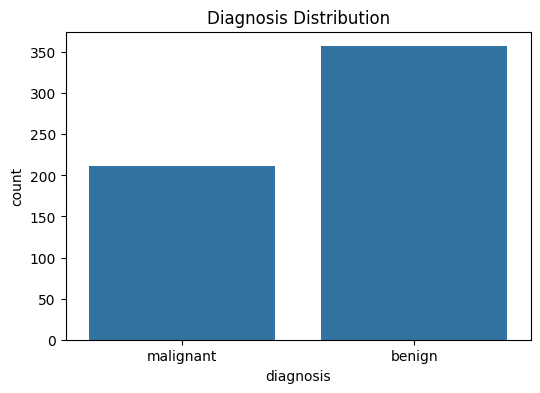

diagnosis
benign       357
malignant    212
Name: count, dtype: int64


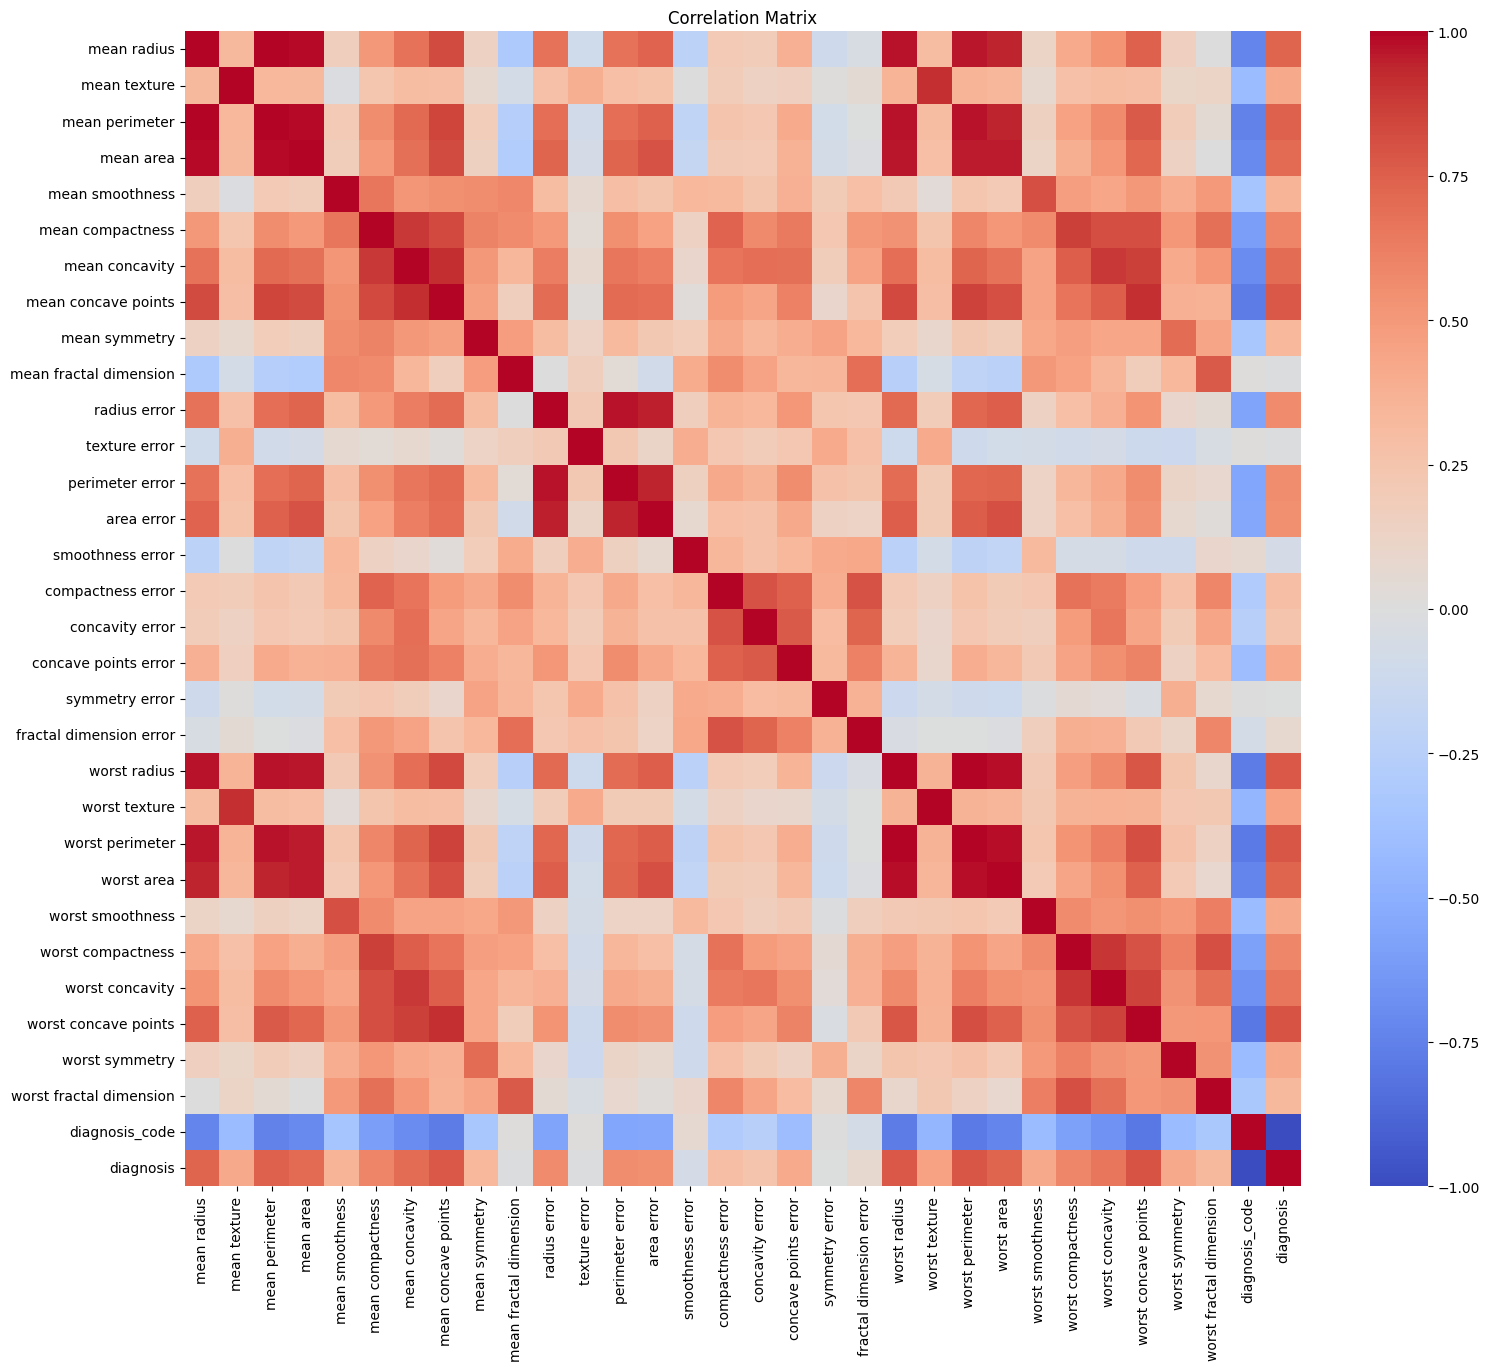

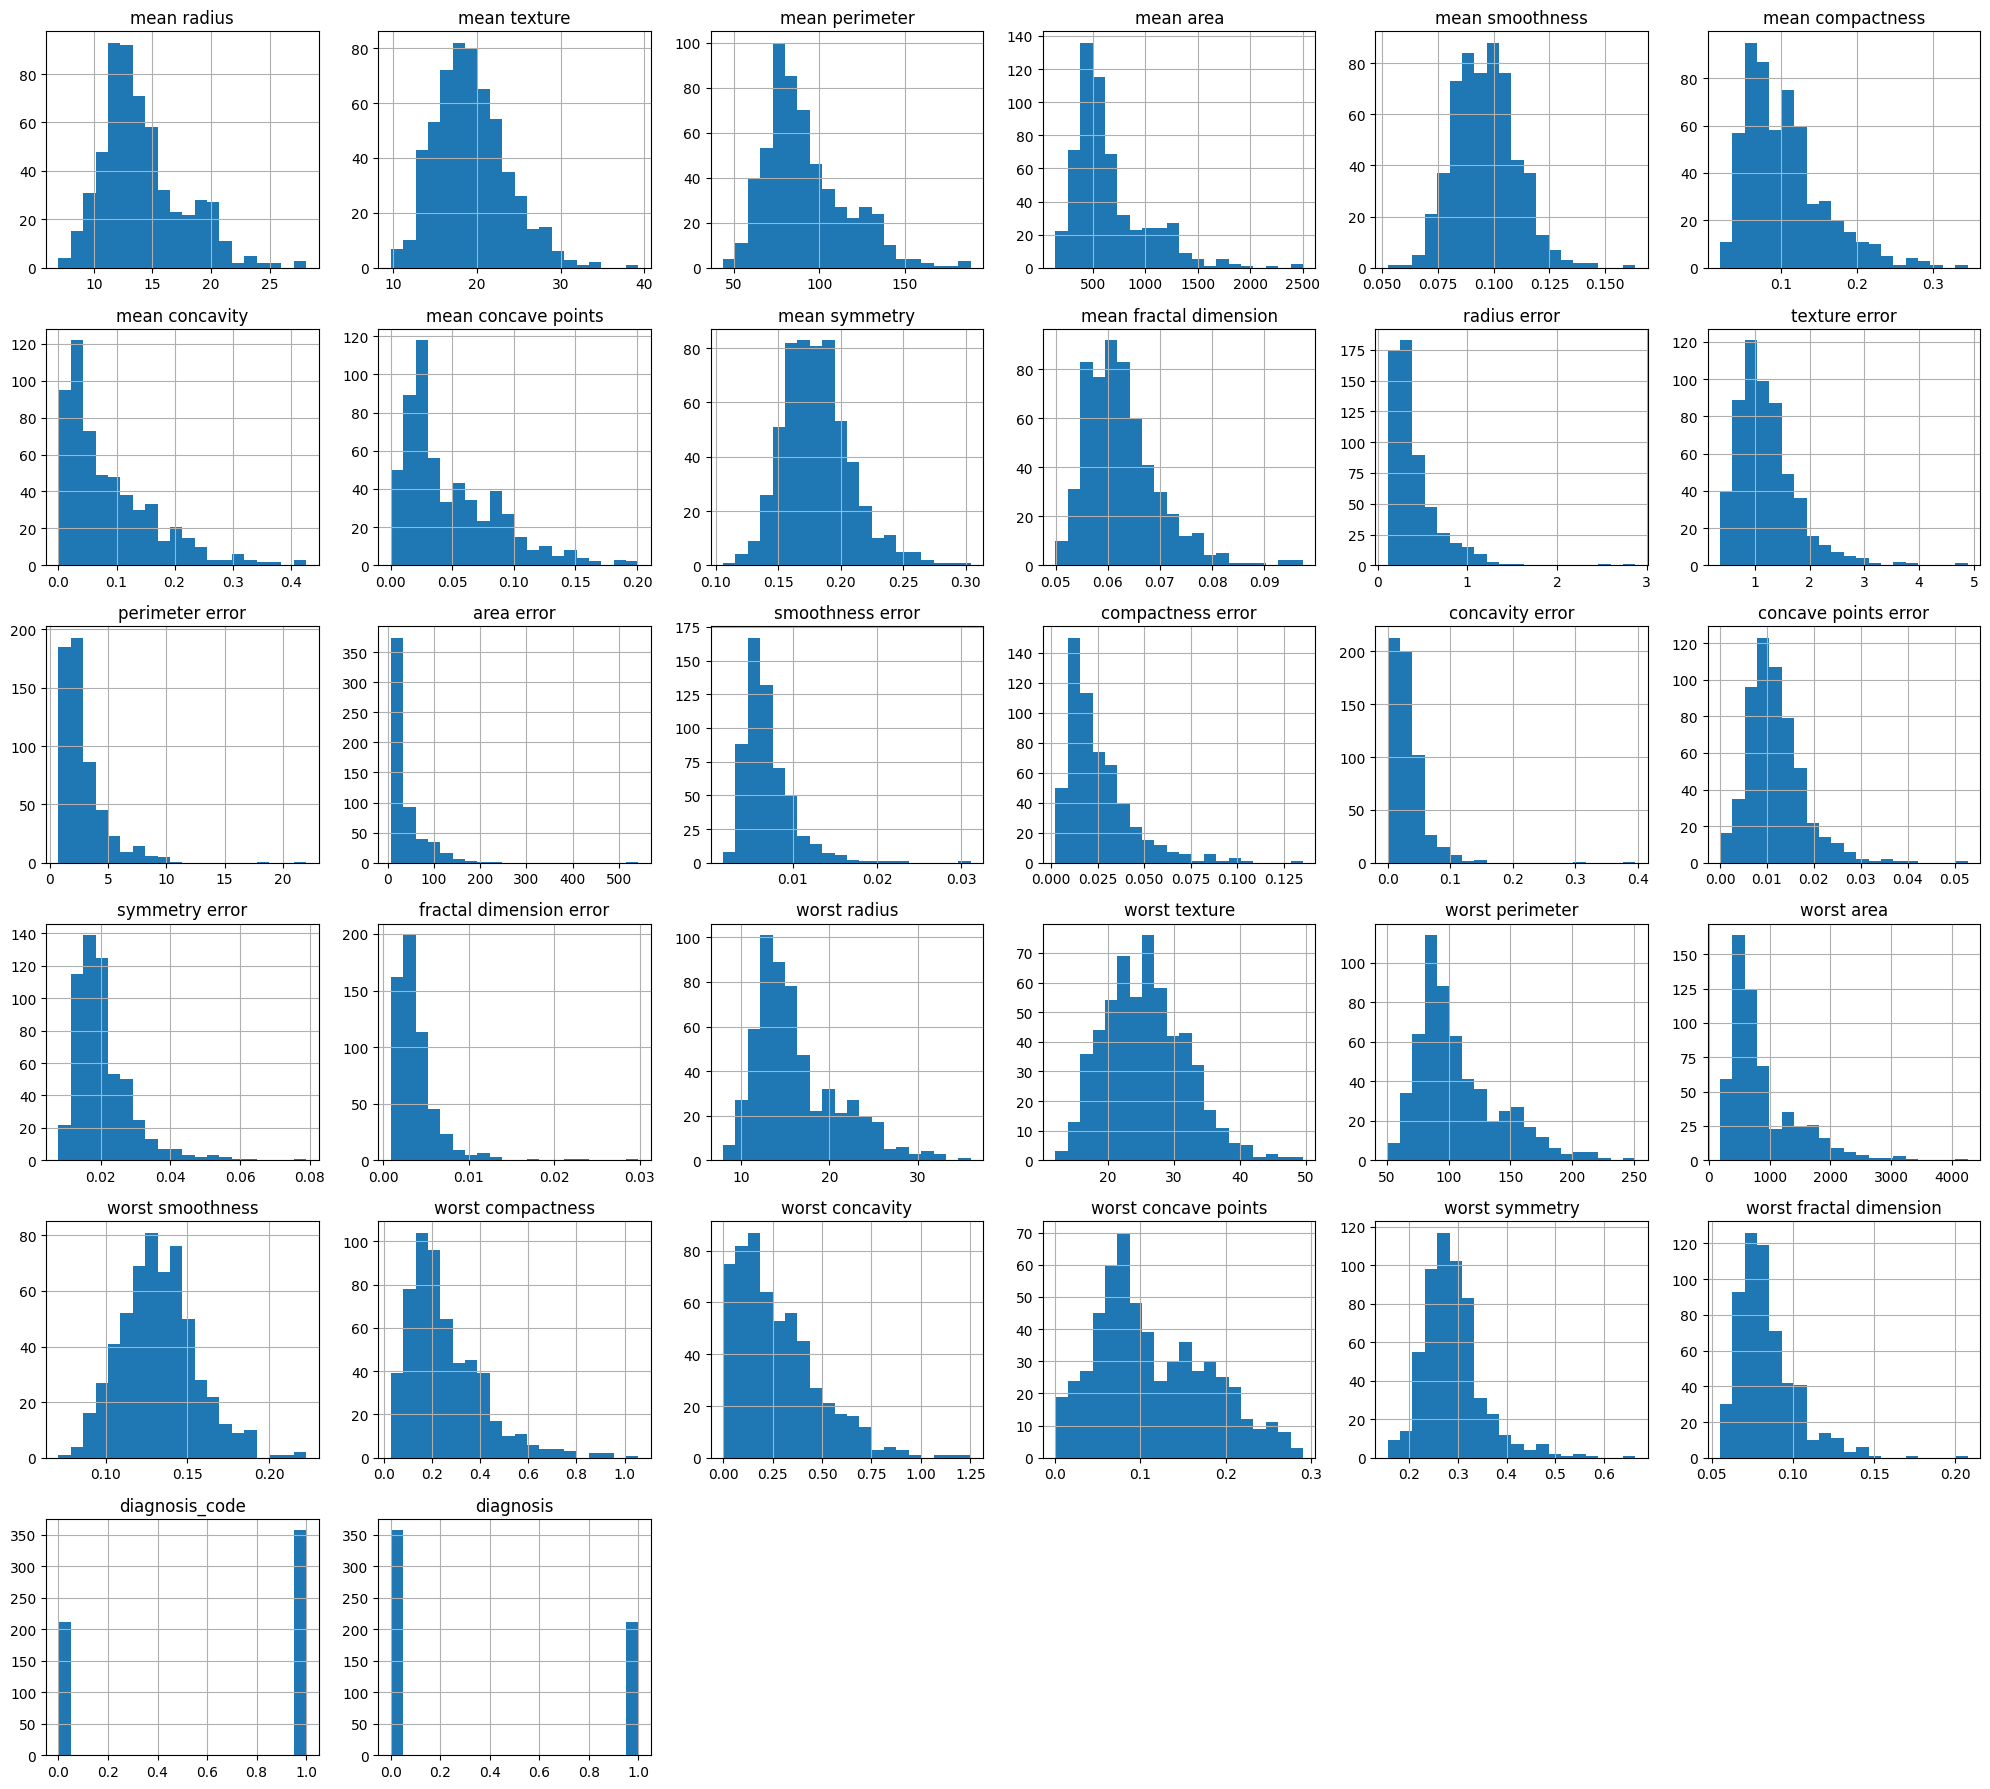

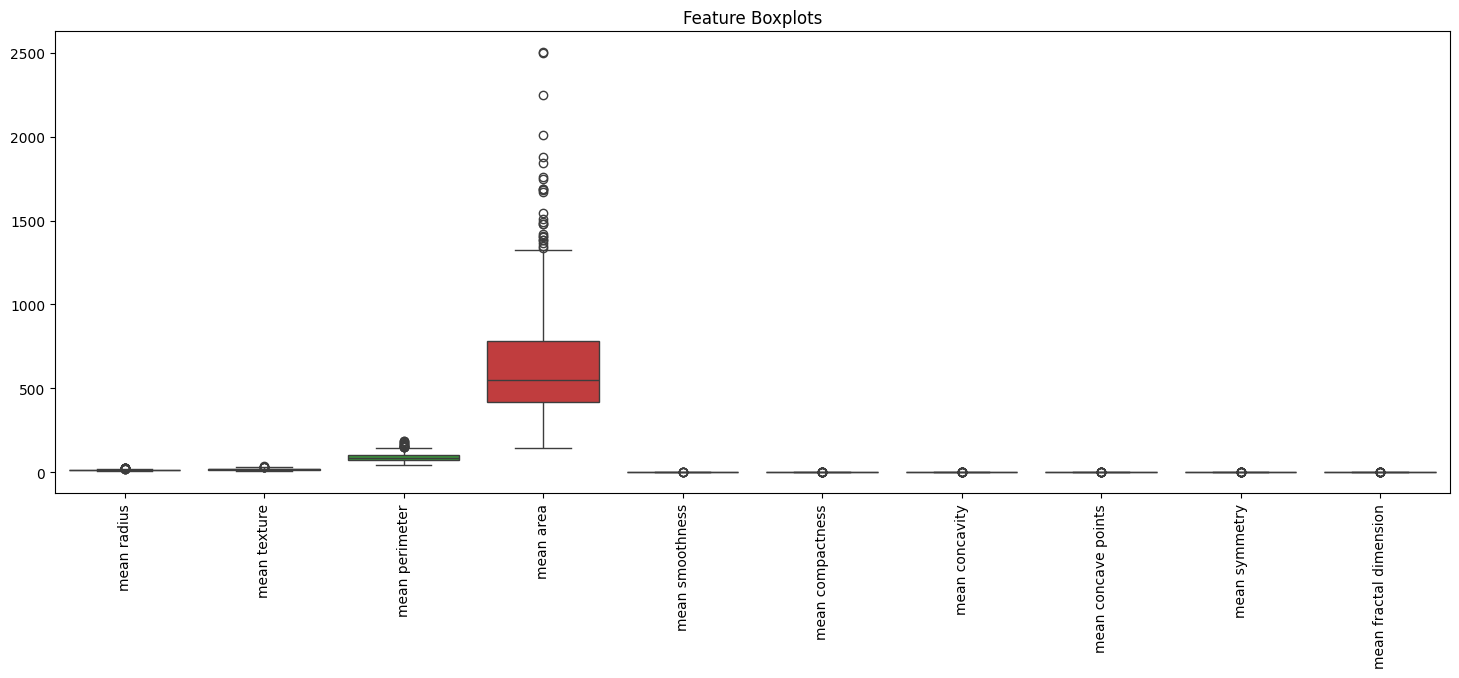

MODEL PERFORMANCE


Logistic Regression
Accuracy : 0.9737
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Decision Tree
Accuracy : 0.9474
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



Random Forest
Accuracy : 0.9649
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
  

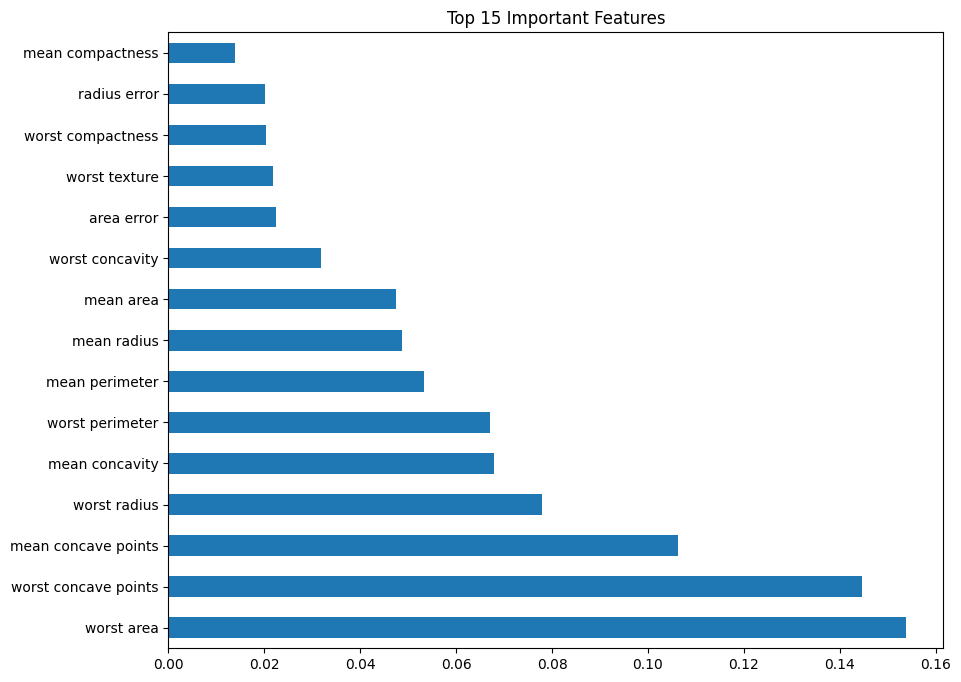

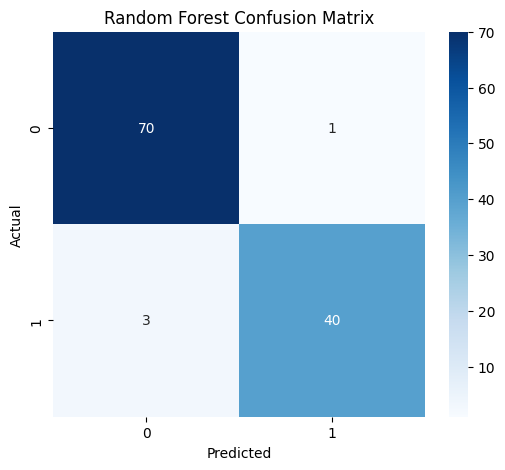

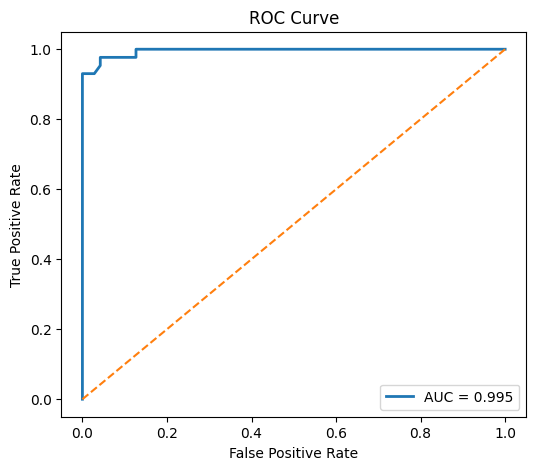

KMEANS CLUSTERING
Clusters = 2 Silhouette Score = 0.3447
Clusters = 3 Silhouette Score = 0.3152
Clusters = 4 Silhouette Score = 0.2742
Clusters = 5 Silhouette Score = 0.1645
Clusters = 6 Silhouette Score = 0.1451
Clusters = 7 Silhouette Score = 0.147


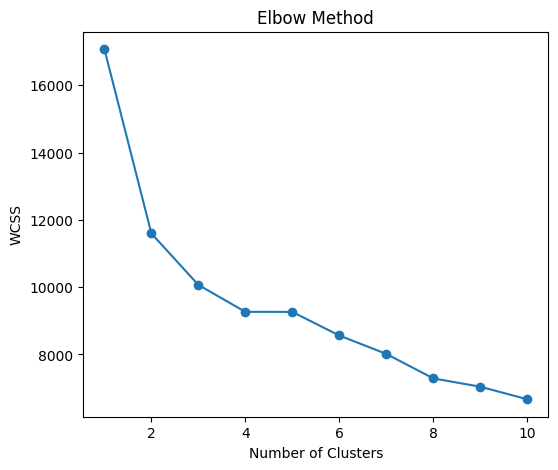

   diagnosis  Cluster
0          1        0
1          1        0
2          1        0
3          1        0
4          1        0


Frequent Itemsets
    support           itemsets
0  0.499121      (mean radius)
1  0.499121     (mean texture)
2  0.499121   (mean perimeter)
3  0.499121        (mean area)
4  0.499121  (mean smoothness)


Association Rules
              antecedents            consequents   support  confidence  \
0        (mean perimeter)          (mean radius)  0.488576    0.978873   
1           (mean radius)       (mean perimeter)  0.488576    0.978873   
2             (mean area)          (mean radius)  0.495606    0.992958   
3           (mean radius)            (mean area)  0.495606    0.992958   
4           (mean radius)         (worst radius)  0.469244    0.940141   
5          (worst radius)          (mean radius)  0.469244    0.943463   
6           (mean radius)      (worst perimeter)  0.462214    0.926056   
7       (worst perimeter)          (mean radius)  

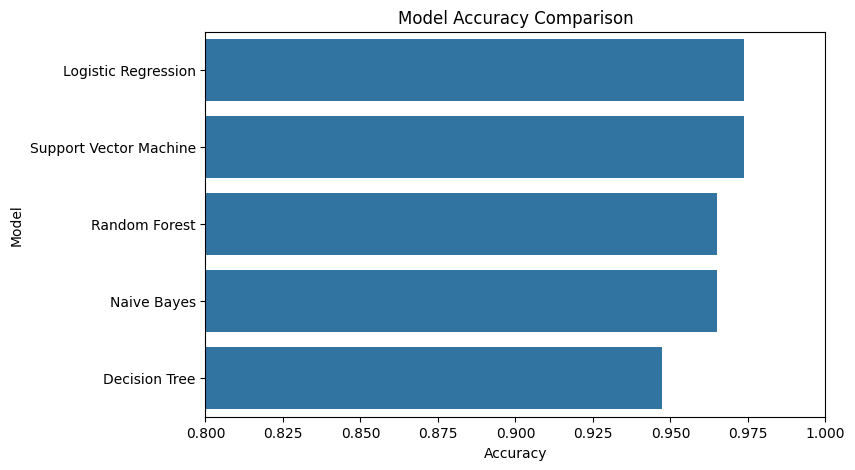



BEST MODEL
Model       Logistic Regression
Accuracy               0.973684
Name: 0, dtype: object


PROJECT COMPLETED SUCCESSFULLY


In [7]:
# ADVANCED BIG DATA & DATA MINING

# Import Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    silhouette_score
)

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

# Load Dataset

df = pd.read_csv("wisconsin_breast_cancer_raw.csv")

print("="*60)
print("Dataset Shape")
print("="*60)
print(df.shape)

print("\n")

print("="*60)
print("First Five Rows")
print("="*60)
print(df.head())

print("\n")

print("="*60)
print("Dataset Information")
print("="*60)
print(df.info())

print("\n")

print("="*60)
print("Summary Statistics")
print("="*60)
print(df.describe())

print("\n")

print("="*60)
print("Missing Values")
print("="*60)
print(df.isnull().sum())

# Class Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    x='diagnosis',
    data=df
)

plt.title("Diagnosis Distribution")

plt.show()

print(df["diagnosis"].value_counts())

# Convert Target Variable

df["diagnosis"] = df["diagnosis"].map({
    "malignant":1,
    "benign":0
})

# Correlation Heatmap

plt.figure(figsize=(18,15))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

# Histograms

df.hist(
    figsize=(20,18),
    bins=20
)

plt.tight_layout()

plt.show()

# Boxplots

plt.figure(figsize=(18,6))

sns.boxplot(data=df.iloc[:,:10])

plt.xticks(rotation=90)

plt.title("Feature Boxplots")

plt.show()

# Feature Engineering

X = df.drop(
    ["diagnosis","diagnosis_code"],
    axis=1
)

y = df["diagnosis"]

# Standardization

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Train Test Split

X_train,X_test,y_train,y_test = train_test_split(

    X_scaled,
    y,

    test_size=0.20,

    random_state=42

)

# Logistic Regression

lr = LogisticRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

# Decision Tree

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)

# Random Forest

rf = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

# Support Vector Machine

svm = SVC(

    probability=True

)

svm.fit(X_train,y_train)

pred_svm = svm.predict(X_test)

# Naive Bayes

nb = GaussianNB()

nb.fit(X_train,y_train)

pred_nb = nb.predict(X_test)

# Model Evaluation

models = {

    "Logistic Regression":pred_lr,

    "Decision Tree":pred_dt,

    "Random Forest":pred_rf,

    "Support Vector Machine":pred_svm,

    "Naive Bayes":pred_nb

}

results=[]

print("="*60)
print("MODEL PERFORMANCE")
print("="*60)

for model,pred in models.items():

    accuracy = accuracy_score(y_test,pred)

    results.append([model,accuracy])

    print("\n")

    print(model)

    print("Accuracy :",round(accuracy,4))

    print(classification_report(y_test,pred))

results = pd.DataFrame(

    results,

    columns=["Model","Accuracy"]

)

print("\n")

print("="*60)
print("Accuracy Comparison")
print("="*60)

print(results.sort_values(

    by="Accuracy",

    ascending=False

))

# Feature Importance

importance = pd.Series(

    rf.feature_importances_,

    index=X.columns

)

importance = importance.sort_values(

    ascending=False

)

plt.figure(figsize=(10,8))

importance.head(15).plot(

    kind="barh"

)

plt.title("Top 15 Important Features")

plt.show()

# Confusion Matrix

cm = confusion_matrix(

    y_test,

    pred_rf

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

# ROC Curve

prob = rf.predict_proba(

    X_test

)[:,1]

fpr,tpr,_ = roc_curve(

    y_test,

    prob

)

roc_auc = auc(

    fpr,

    tpr

)

plt.figure(figsize=(6,5))

plt.plot(

    fpr,

    tpr,

    linewidth=2,

    label="AUC = %.3f"%roc_auc

)

plt.plot(

    [0,1],

    [0,1],

    '--'

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# KMeans Clustering

print("="*60)
print("KMEANS CLUSTERING")
print("="*60)

scores=[]

for k in range(2,8):

    km = KMeans(

        n_clusters=k,

        random_state=42

    )

    labels = km.fit_predict(

        X_scaled

    )

    score = silhouette_score(

        X_scaled,

        labels

    )

    scores.append(score)

    print("Clusters =",k,

          "Silhouette Score =",round(score,4))

# Elbow Method

wcss=[]

for i in range(1,11):

    km = KMeans(

        n_clusters=i,

        random_state=42

    )

    km.fit(

        X_scaled

    )

    wcss.append(

        km.inertia_

    )

plt.figure(figsize=(6,5))

plt.plot(

    range(1,11),

    wcss,

    marker='o'

)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

# Final KMeans

kmeans = KMeans(

    n_clusters=2,

    random_state=42

)

clusters = kmeans.fit_predict(

    X_scaled

)

df["Cluster"] = clusters

print(df[["diagnosis","Cluster"]].head())

# Association Rule Mining

binary_df = df.copy()

for col in X.columns:

    binary_df[col] = (

        binary_df[col] >

        binary_df[col].median()

    ).astype(int)

frequent = apriori(

    binary_df[X.columns],

    min_support=0.30,

    use_colnames=True

)

print("\n")

print("="*60)
print("Frequent Itemsets")
print("="*60)

print(frequent.head())

rules = association_rules(

    frequent,

    metric="confidence",

    min_threshold=0.80

)

print("\n")

print("="*60)
print("Association Rules")
print("="*60)

print(

rules[

["antecedents",

"consequents",

"support",

"confidence",

"lift"]

].head(20)

)

# Final Accuracy Graph

plt.figure(figsize=(8,5))

sns.barplot(

    data=results.sort_values(

        by="Accuracy",

        ascending=False

    ),

    x="Accuracy",

    y="Model"

)

plt.title("Model Accuracy Comparison")

plt.xlim(0.80,1.00)

plt.show()
# Best Model
best = results.sort_values(

    by="Accuracy",

    ascending=False

)

print("\n")

print("="*60)
print("BEST MODEL")
print("="*60)

print(best.iloc[0])

print("\n")

print("="*60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*60)